In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches



%matplotlib notebook
import random

<IPython.core.display.Javascript object>


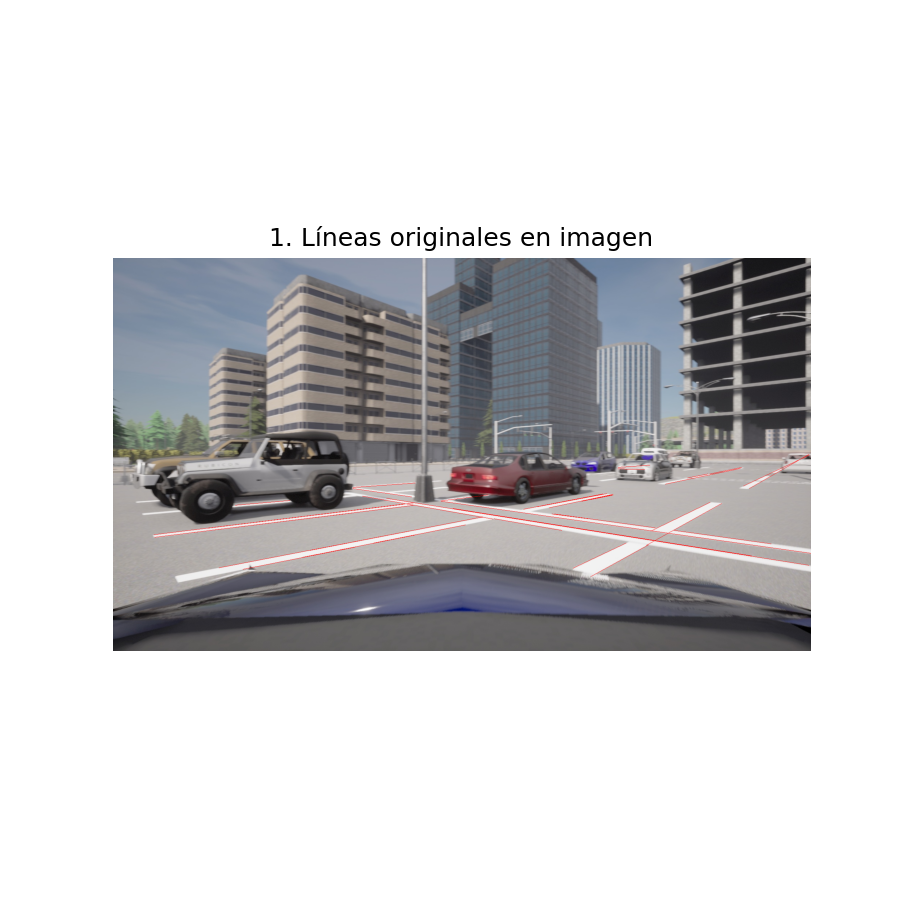

<IPython.core.display.Javascript object>


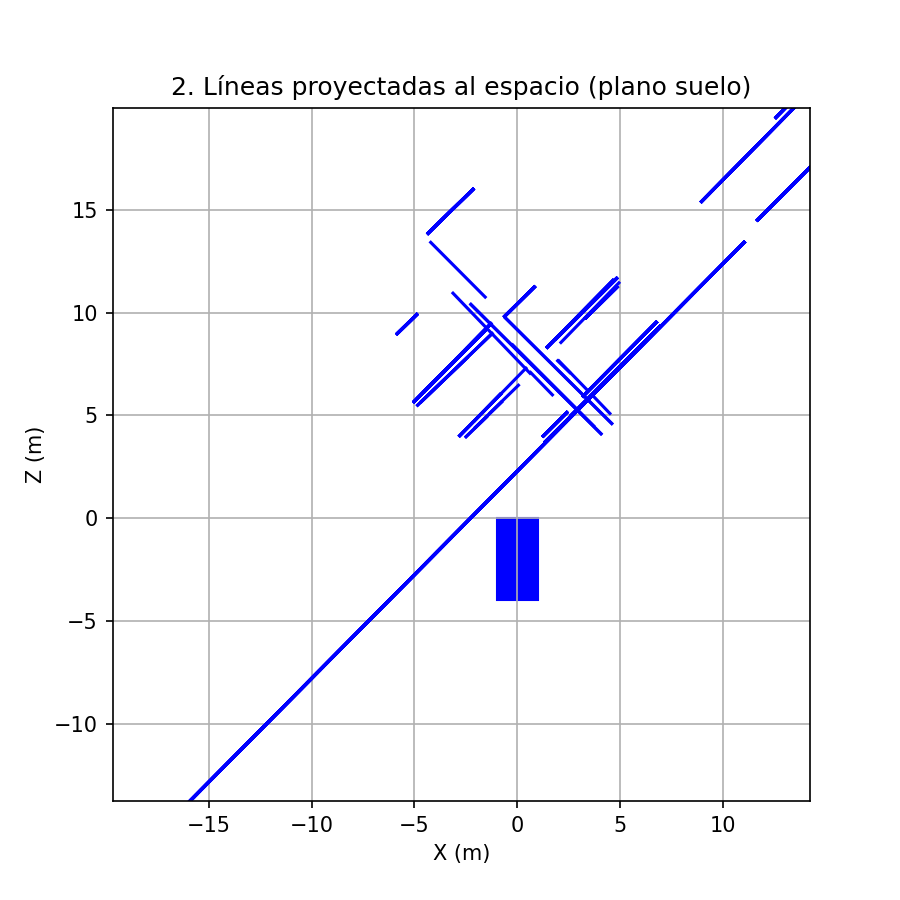

<IPython.core.display.Javascript object>


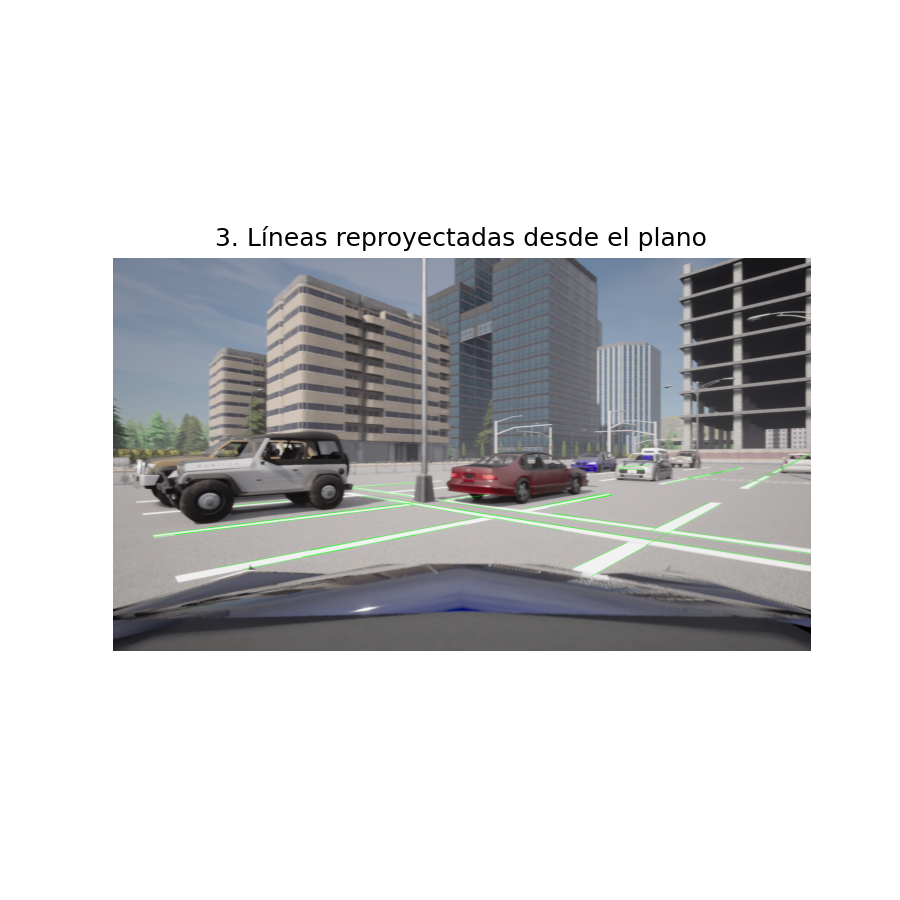

In [3]:
# Datos conocidos
image_width, image_height = 1920, 1080
fov = 90  # grados
camera_height = 1.3  # metros

# Cargar imagen y líneas
img = cv2.imread('vp.jpg')
lines_near_vps = np.load('lines_near_vps.npy')

# Copias para gráficos
img_lines = img.copy()
img_reprojected = img.copy()
ground_lines = []

# Calcular focal en píxeles
f = image_width / (2 * np.tan(np.radians(fov / 2)))
cx, cy = image_width / 2, image_height / 2

# Matriz intrínseca
K = np.array([
    [f, 0, cx],
    [0, f, cy],
    [0, 0, 1]
])
K_inv = np.linalg.inv(K)

for line in lines_near_vps:
    x1, y1, x2, y2 = line[0]

    # Dibujar línea original en rojo
    cv2.line(img_lines, (x1, y1), (x2, y2), (0, 0, 255), 1)

    # Proyección al espacio
    p1_img = np.array([x1, y1, 1])
    p2_img = np.array([x2, y2, 1])

    # Rayos en cámara
    r1_cam = K_inv @ p1_img
    r2_cam = K_inv @ p2_img

    # Escalar rayos para intersectar el plano Z=0 (suelo)
    scale1 = camera_height / r1_cam[1]
    scale2 = camera_height / r2_cam[1]

    p1_ground = r1_cam * scale1
    p2_ground = r2_cam * scale2

    ground_lines.append((p1_ground, p2_ground))

    # Reproyección a imagen
    p1_proj = K @ p1_ground
    p1_proj /= p1_proj[2]

    p2_proj = K @ p2_ground
    p2_proj /= p2_proj[2]

    # Dibujar línea reproyectada en verde
    pt1_proj = (int(p1_proj[0]), int(r2p1_proj[1]))
    pt2_proj = (int(p2_proj[0]), int(p2_proj[1]))
    cv2.line(img_reprojected, pt1_proj, pt2_proj, (0, 255, 0), 1)

# === Graficar ===
# Imagen original con líneas rojas
fig1 = plt.figure(figsize=(6, 6))
plt.imshow(cv2.cvtColor(img_lines, cv2.COLOR_BGR2RGB))
plt.title("1. Líneas originales en imagen")
plt.axis("off")
plt.show()

# Plano del suelo (top view)
fig2 = plt.figure(figsize=(6, 6))
for p1, p2 in ground_lines:
    plt.plot([p1[0], p2[0]], [p1[2], p2[2]], 'b-')  # Ejes X-Z

# Dibujar el rectángulo azul (carrito)
car_x, car_z = -1, -4  # Coordenadas iniciales del carrito
car_width, car_length = 2, 4  # Ancho y largo del carrito
rect = patches.Rectangle((car_x, car_z), car_width, car_length, linewidth=1, edgecolor='blue', facecolor='blue')
plt.gca().add_patch(rect)

plt.title("2. Líneas proyectadas al espacio (plano suelo)")
plt.xlabel("X (m)")
plt.ylabel("Z (m)")
plt.axis("equal")
plt.grid(True)

plt.show()

# Imagen con líneas reproyectadas (verde)
fig3 = plt.figure(figsize=(6, 6))
plt.imshow(cv2.cvtColor(img_reprojected, cv2.COLOR_BGR2RGB))
plt.title("3. Líneas reproyectadas desde el plano")
plt.axis("off")
plt.show()


In [4]:
r1_cam


array([-0.02604167,  0.15416667,  1.        ])